In [357]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler

from sklearn.impute import SimpleImputer

from sklearn.linear_model import LinearRegression, LogisticRegression

from sklearn.cluster import KMeans

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score,
    accuracy_score,
    confusion_matrix,
    classification_report
)
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

sns.set_style("whitegrid")

pd.set_option("display.max_columns", None)

In [358]:
file_path = "Processed Data.xlsx"

excel_file = pd.ExcelFile(file_path)

excel_file.sheet_names

['baggage',
 'flights',
 'gate_events',
 'maintenance_logs',
 'passengers',
 'retail_transaction',
 'security_screening',
 'staff_shifts',
 'Date']

In [359]:
flights = pd.read_excel(file_path, sheet_name="flights")
passengers = pd.read_excel(file_path, sheet_name="passengers")
baggage = pd.read_excel(file_path, sheet_name="baggage")
gate_events = pd.read_excel(file_path, sheet_name="gate_events")
maintenance = pd.read_excel(file_path, sheet_name="maintenance_logs")
retail = pd.read_excel(file_path, sheet_name="retail_transaction")
security = pd.read_excel(file_path, sheet_name="security_screening")
staff = pd.read_excel(file_path, sheet_name="staff_shifts")
date_table = pd.read_excel(file_path, sheet_name="Date")

In [360]:
datasets = {
    "Flights": flights,
    "Passengers": passengers,
    "Baggage": baggage,
    "Gate Events": gate_events,
    "Maintenance": maintenance,
    "Retail": retail,
    "Security": security,
    "Staff": staff
}

for name, df in datasets.items():
    print("=" * 70)
    print(name)
    print(df.shape)
    # print(df.head())

Flights
(996, 29)
Passengers
(2204, 20)
Baggage
(791, 13)
Gate Events
(1200, 8)
Maintenance
(394, 8)
Retail
(2999, 9)
Security
(2500, 8)
Staff
(600, 9)


In [361]:
for name, df in datasets.items():

    print("=" * 70)
    print(name)

    print(df.info(), '\n')
    print(df.isnull().sum(), '\n')

Flights
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 996 entries, 0 to 995
Data columns (total 29 columns):
 #   Column                   Non-Null Count  Dtype         
---  ------                   --------------  -----         
 0   flight_id                996 non-null    object        
 1   airline_name             996 non-null    object        
 2   airline_code             996 non-null    object        
 3   destination_airport      996 non-null    object        
 4   scheduled_departure      996 non-null    datetime64[ns]
 5   actual_departure         996 non-null    datetime64[ns]
 6   scheduled_arrival        996 non-null    datetime64[ns]
 7   actual_arrival           996 non-null    datetime64[ns]
 8   aircraft_type            996 non-null    object        
 9   aircraft_registration    996 non-null    object        
 10  seat_capacity            996 non-null    int64         
 11  passenger_count          996 non-null    int64         
 12  departure_delay_minutes  996

In [362]:
for name, df in datasets.items():

    numeric_cols = df.select_dtypes(include=np.number).columns

    categorical_cols = df.select_dtypes(include="object").columns

    for col in numeric_cols:

        df[col] = df[col].fillna(df[col].median())

    for col in categorical_cols:

        df[col] = df[col].fillna(df[col].mode()[0])

In [363]:
for name, df in datasets.items():

    print(name)

    print(df.duplicated().sum())

    df.drop_duplicates(inplace=True)

    print("Duplicates Removed\n")

Flights
0
Duplicates Removed

Passengers
0
Duplicates Removed

Baggage
0
Duplicates Removed

Gate Events
0
Duplicates Removed

Maintenance
0
Duplicates Removed

Retail
0
Duplicates Removed

Security
0
Duplicates Removed

Staff
0
Duplicates Removed



In [364]:
for name, df in datasets.items():

    print("=" * 70)

    print(name)

    print(df.describe(include="all"))

Flights
       flight_id airline_name airline_code destination_airport  \
count        996          996          996                 996   
unique       996           12           12                  14   
top      SG-1280    Lufthansa           LH                 JFK   
freq           1           95           95                  84   
mean         NaN          NaN          NaN                 NaN   
min          NaN          NaN          NaN                 NaN   
25%          NaN          NaN          NaN                 NaN   
50%          NaN          NaN          NaN                 NaN   
75%          NaN          NaN          NaN                 NaN   
max          NaN          NaN          NaN                 NaN   
std          NaN          NaN          NaN                 NaN   

                  scheduled_departure               actual_departure  \
count                             996                            996   
unique                            NaN                  

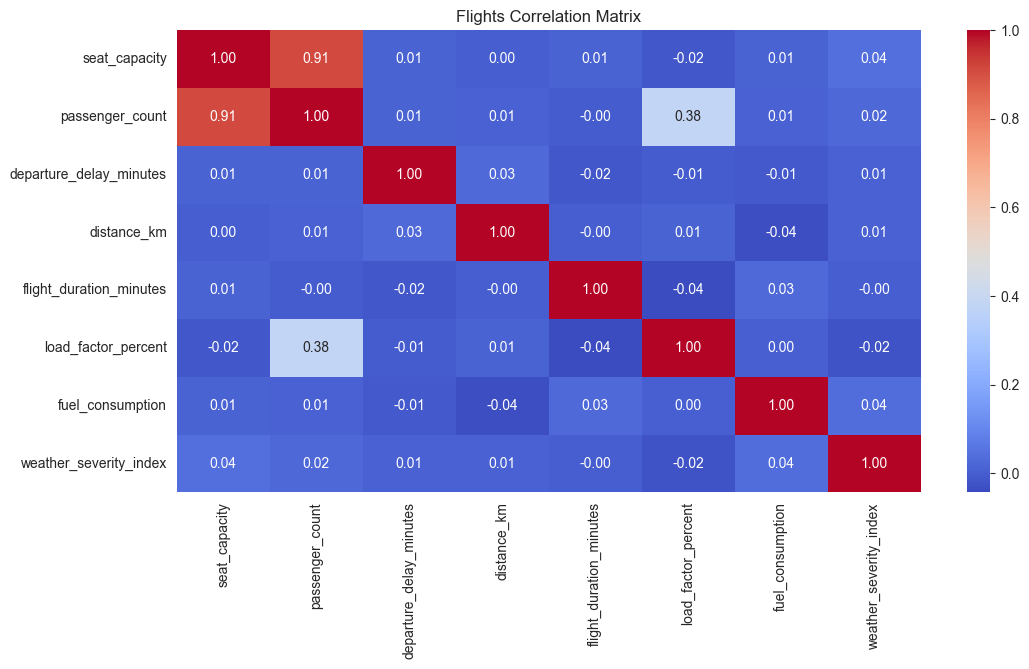

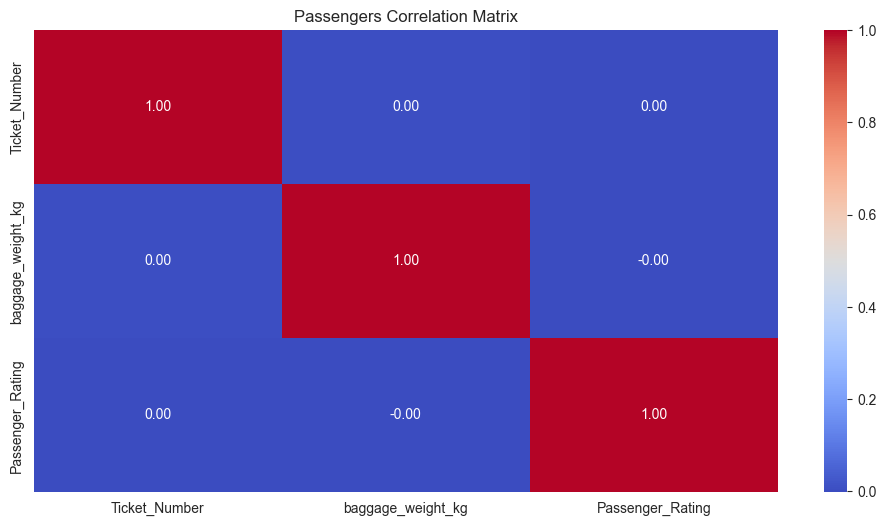

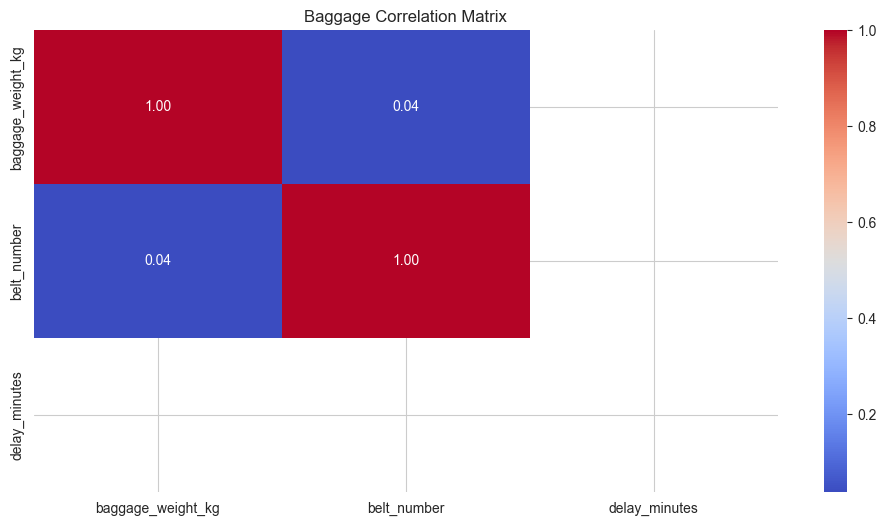

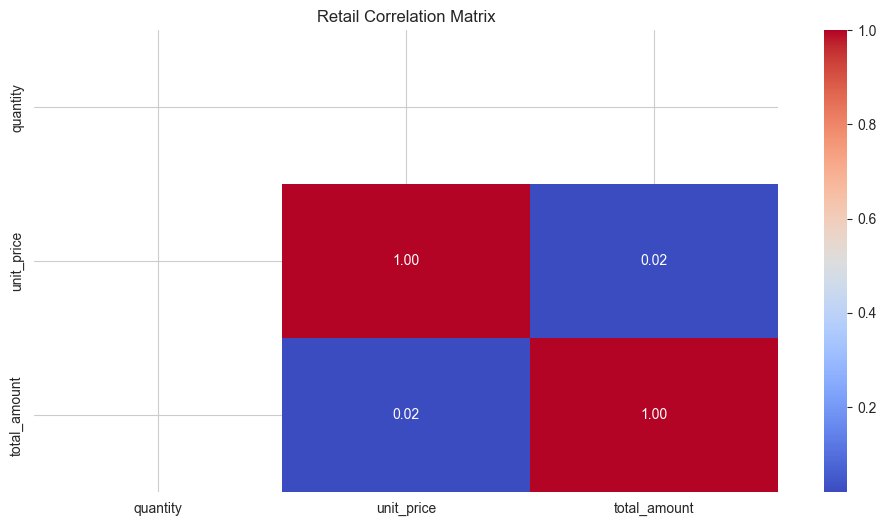

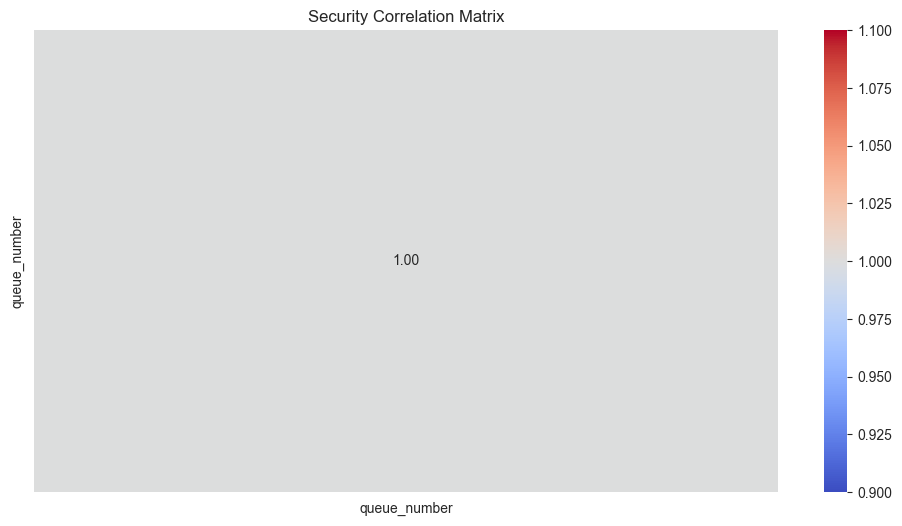

In [365]:
for name, df in datasets.items():

    numeric = df.select_dtypes(include=np.number)

    if numeric.shape[1] > 0:

        plt.figure(figsize=(12,6))

        sns.heatmap(
            numeric.corr(),
            annot=True,
            cmap="coolwarm",
            fmt=".2f"
        )

        plt.title(f"{name} Correlation Matrix")

        plt.show()

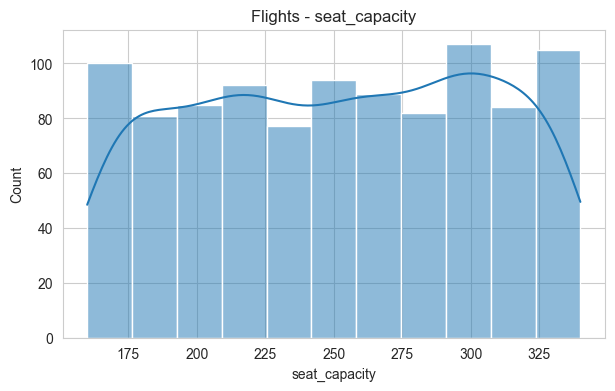

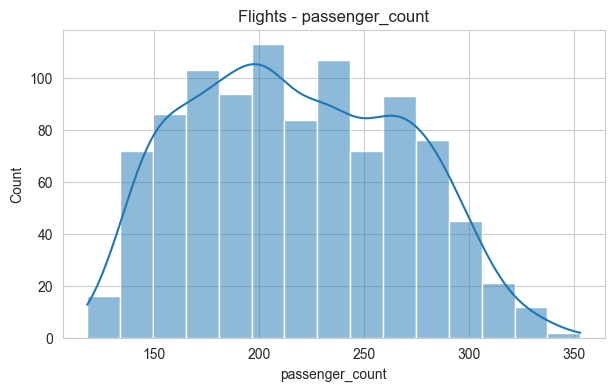

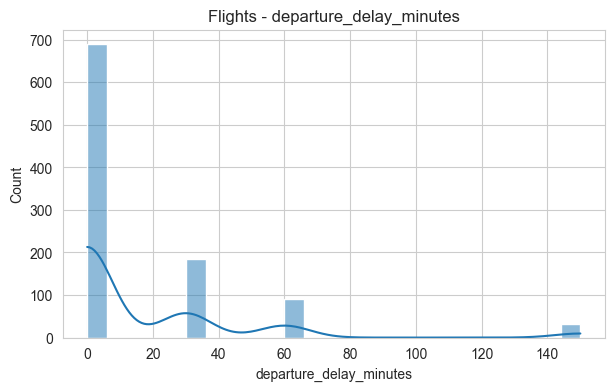

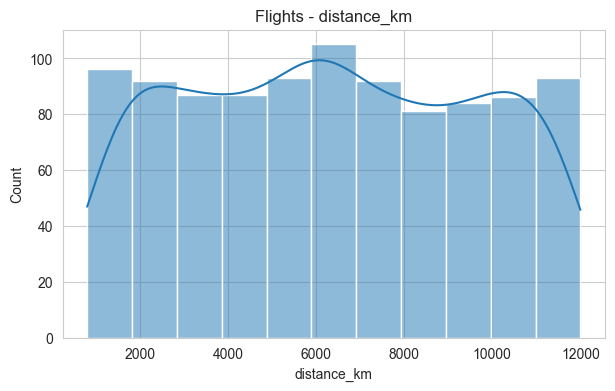

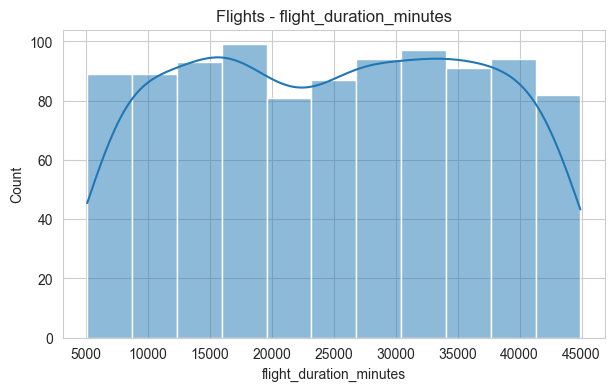

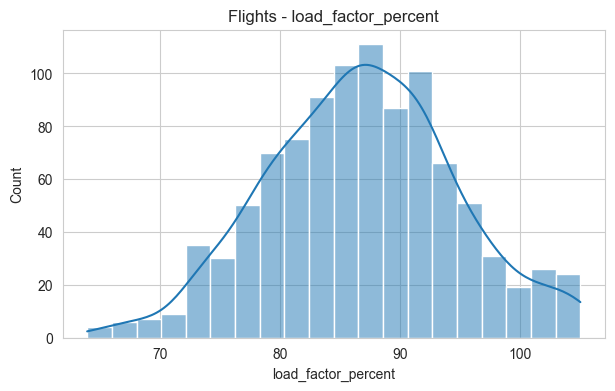

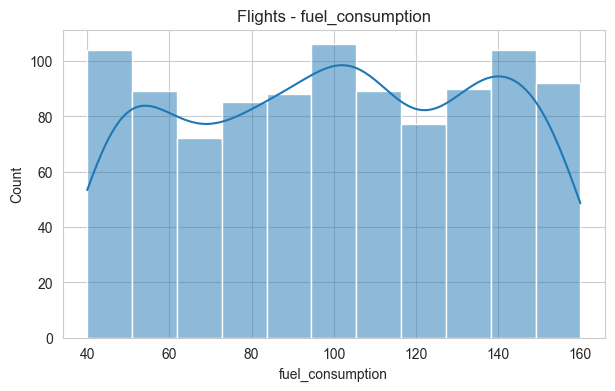

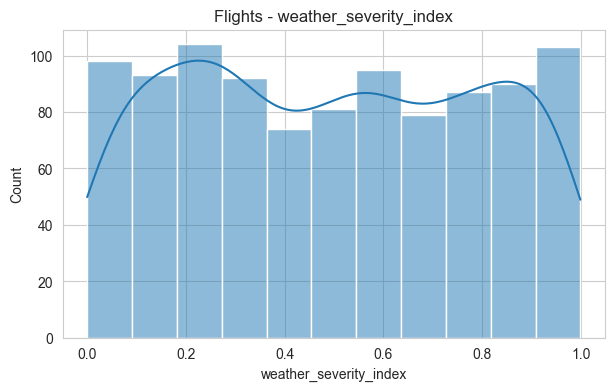

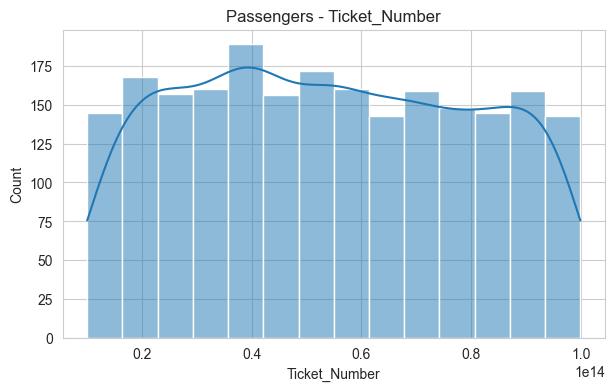

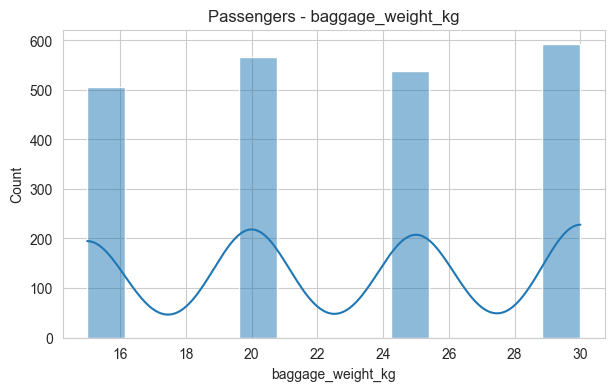

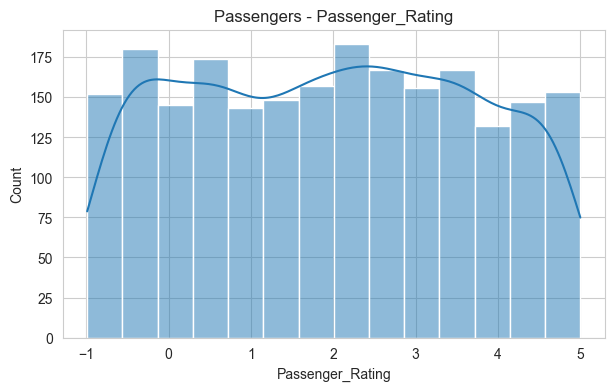

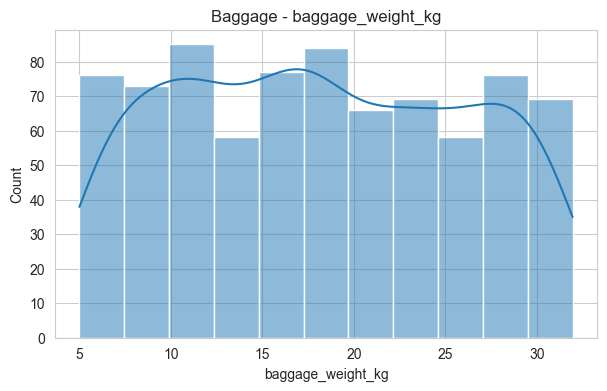

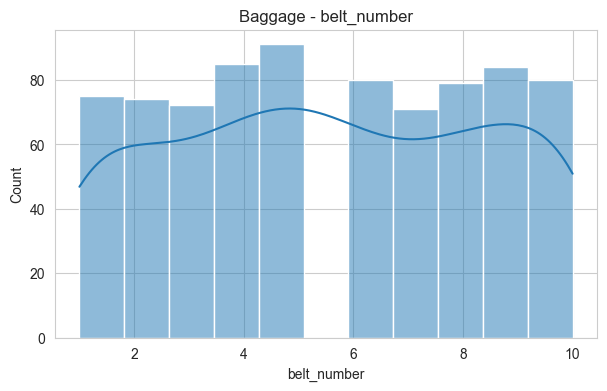

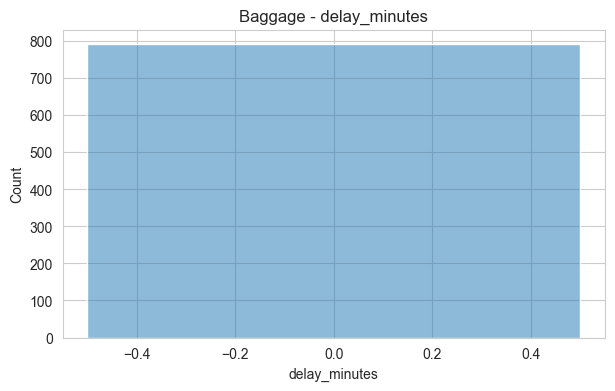

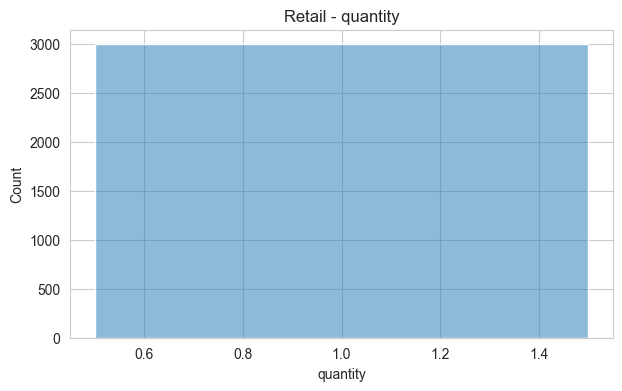

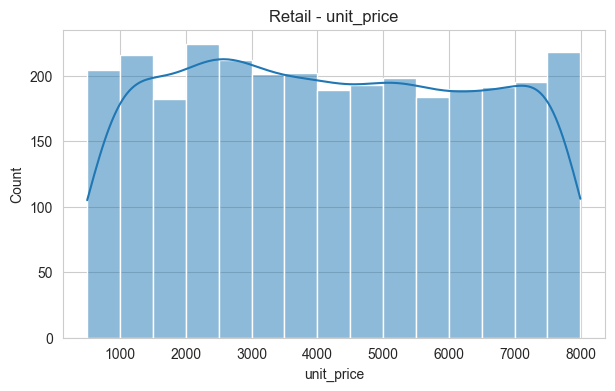

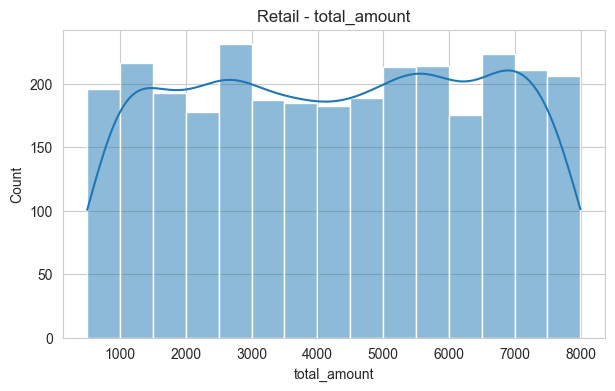

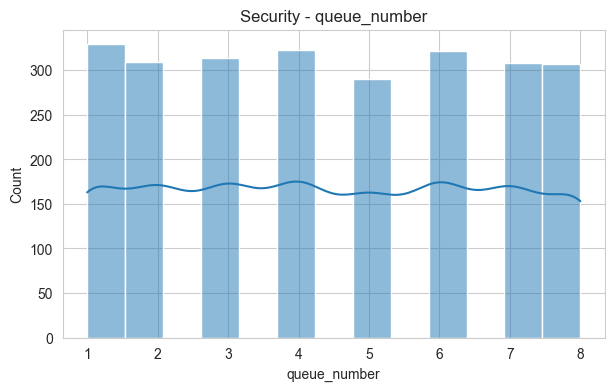

In [366]:
for name, df in datasets.items():

    numeric_cols = df.select_dtypes(include=np.number).columns

    for col in numeric_cols:

        plt.figure(figsize=(7,4))

        sns.histplot(df[col], kde=True)

        plt.title(f"{name} - {col}")

        plt.show()

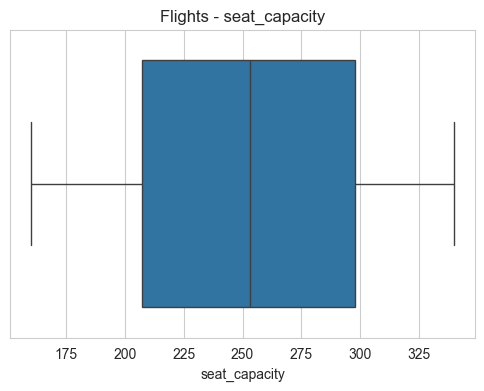

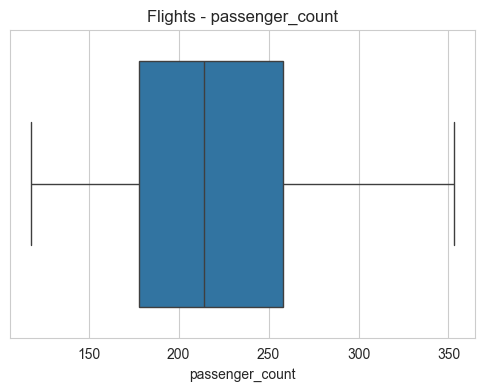

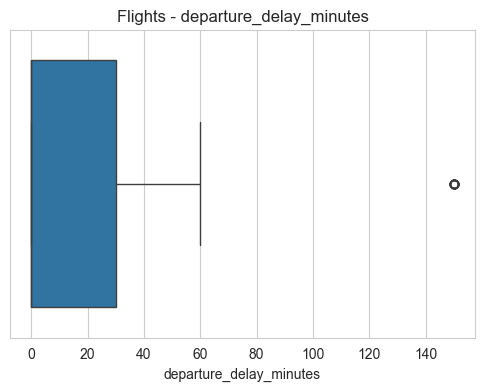

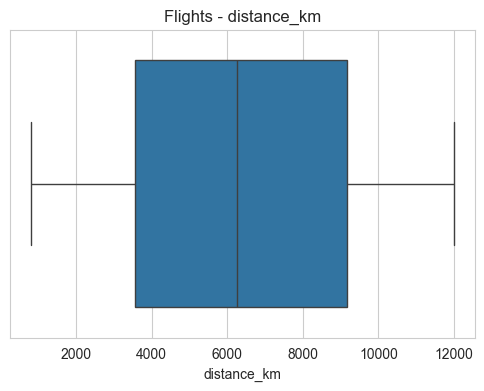

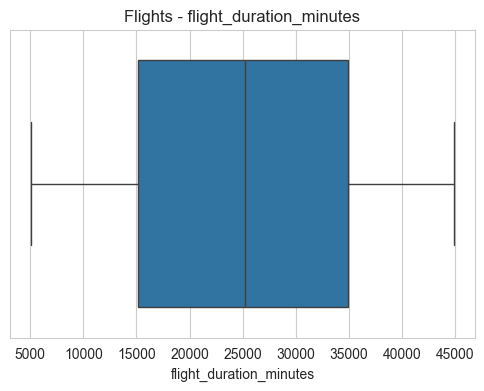

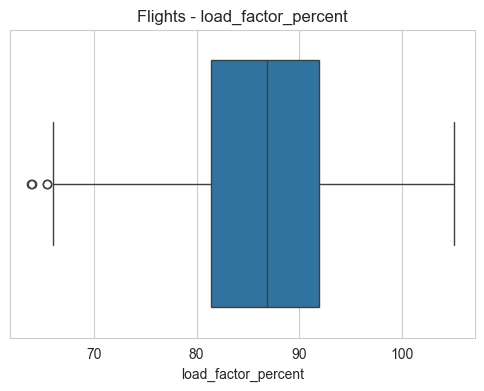

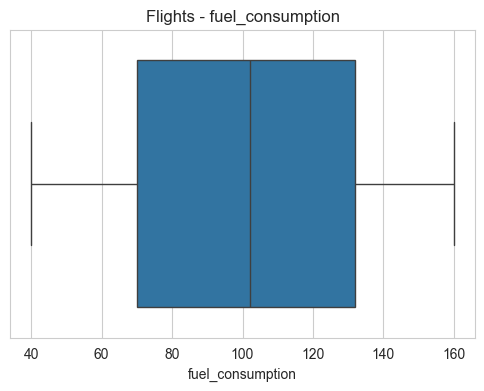

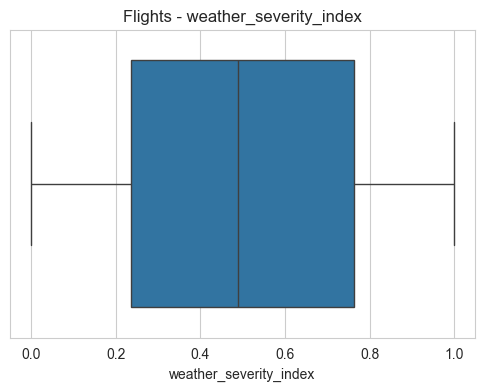

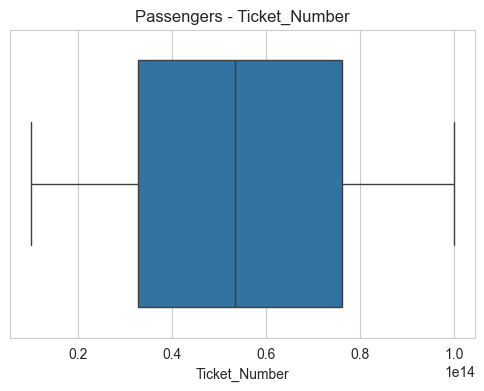

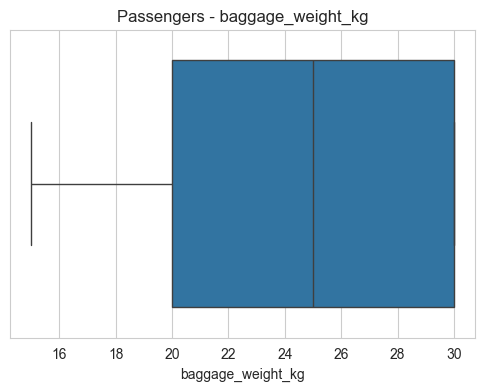

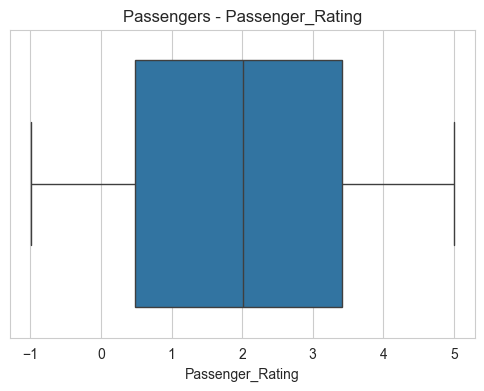

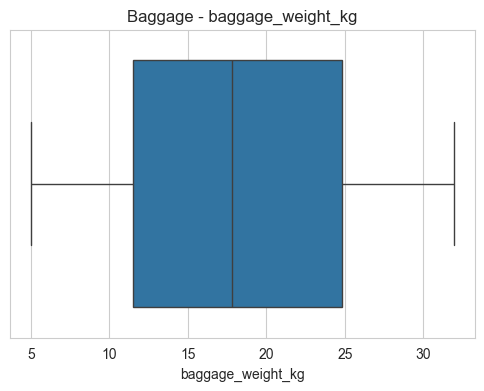

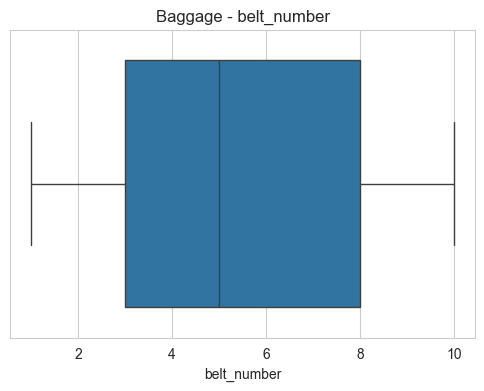

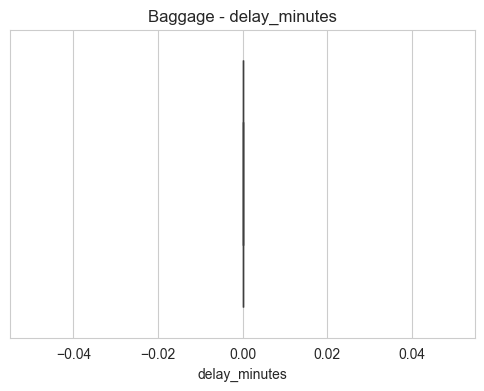

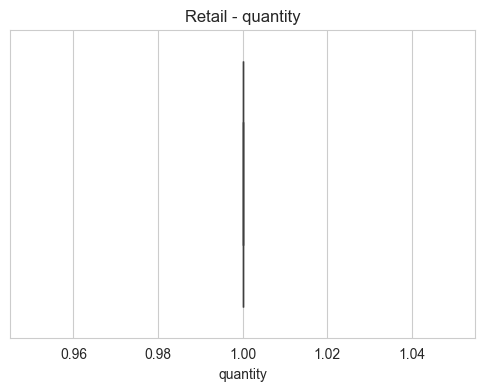

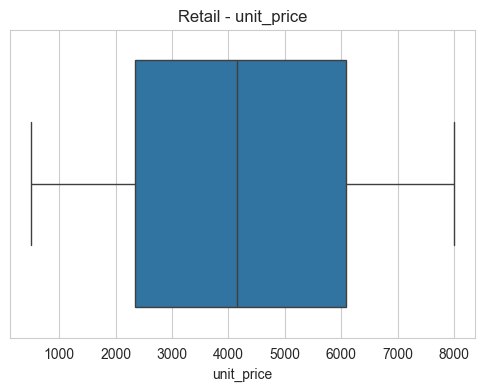

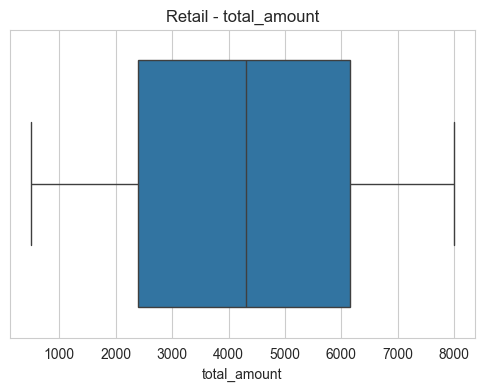

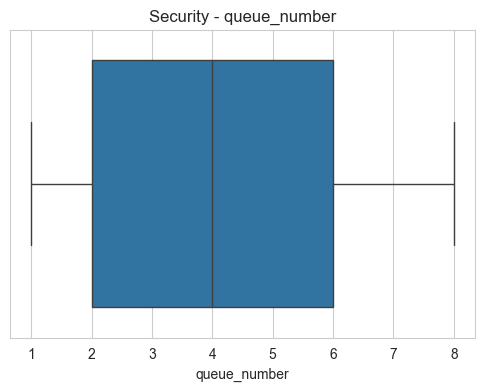

In [367]:
for name, df in datasets.items():

    numeric_cols = df.select_dtypes(include=np.number).columns

    for col in numeric_cols:

        plt.figure(figsize=(6,4))

        sns.boxplot(x=df[col])

        plt.title(f"{name} - {col}")

        plt.show()
    

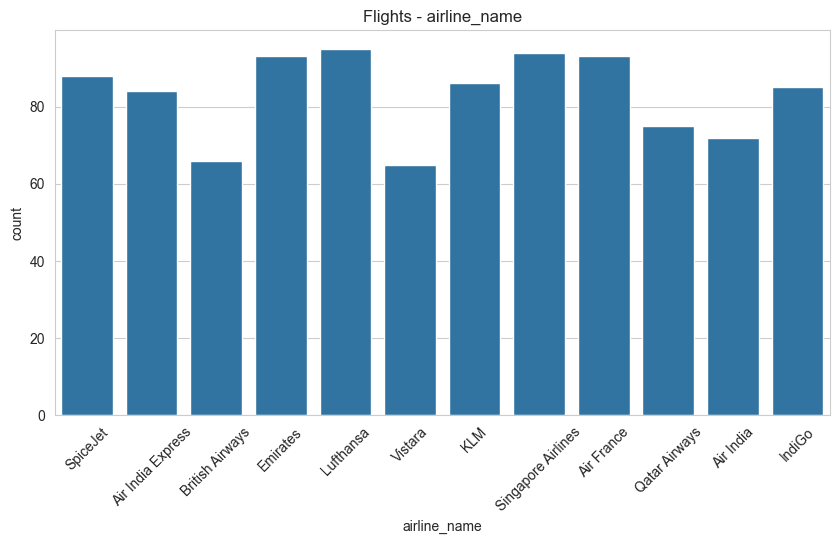

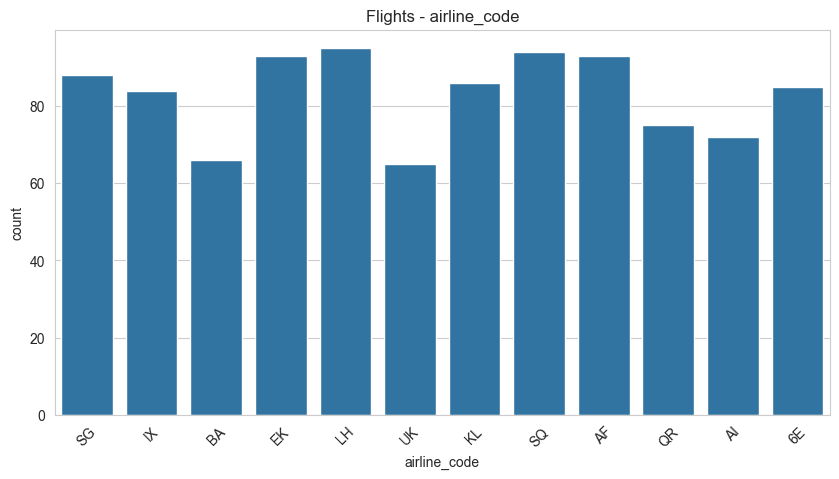

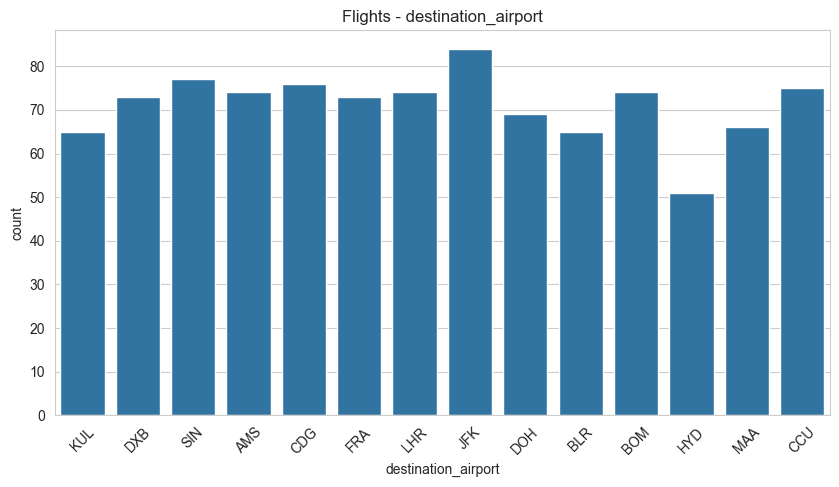

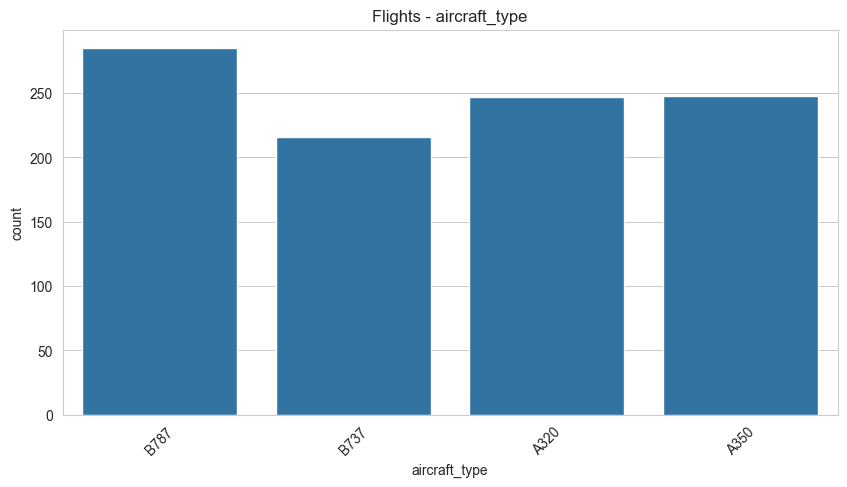

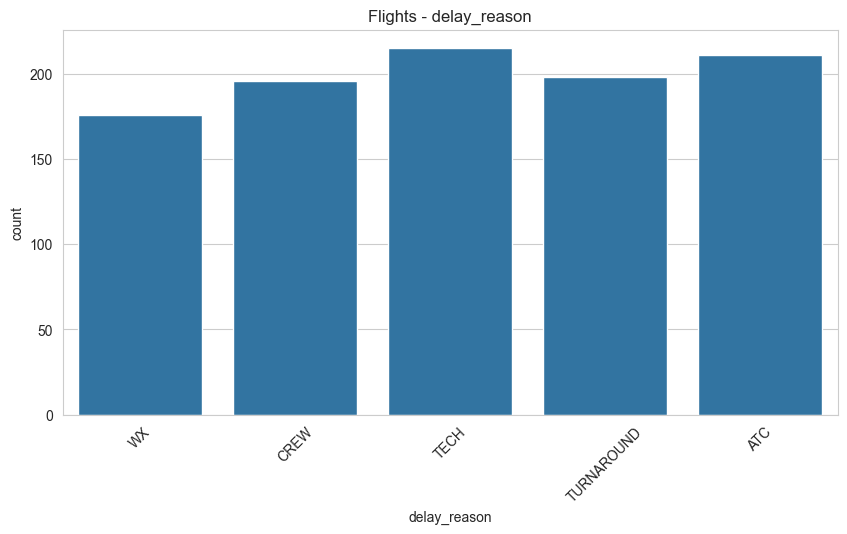

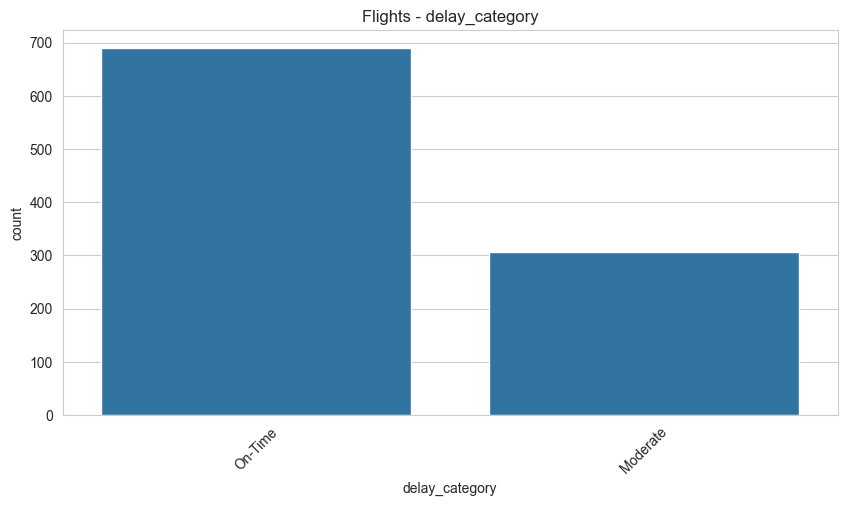

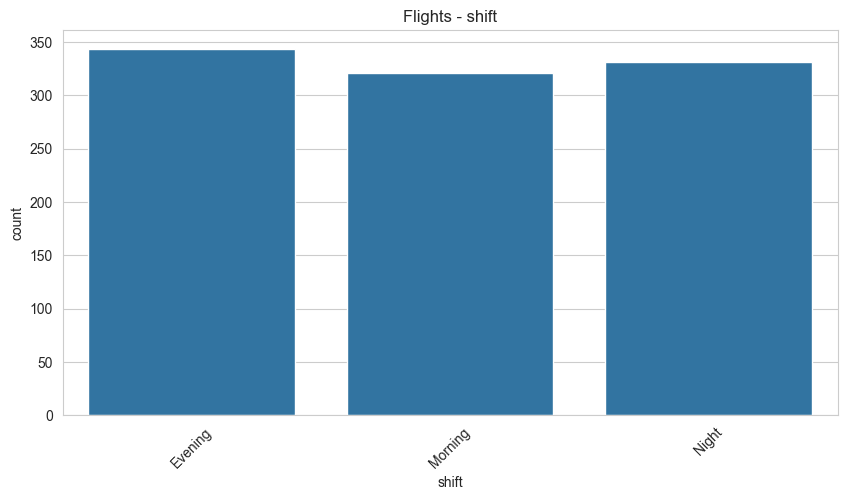

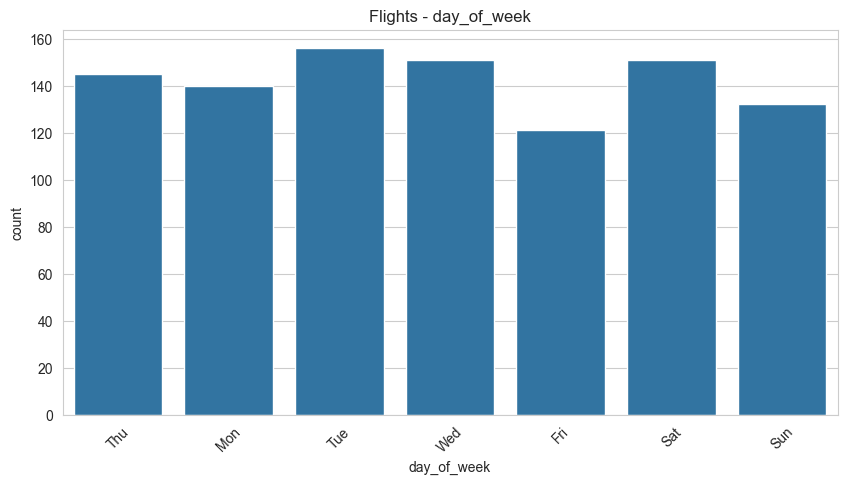

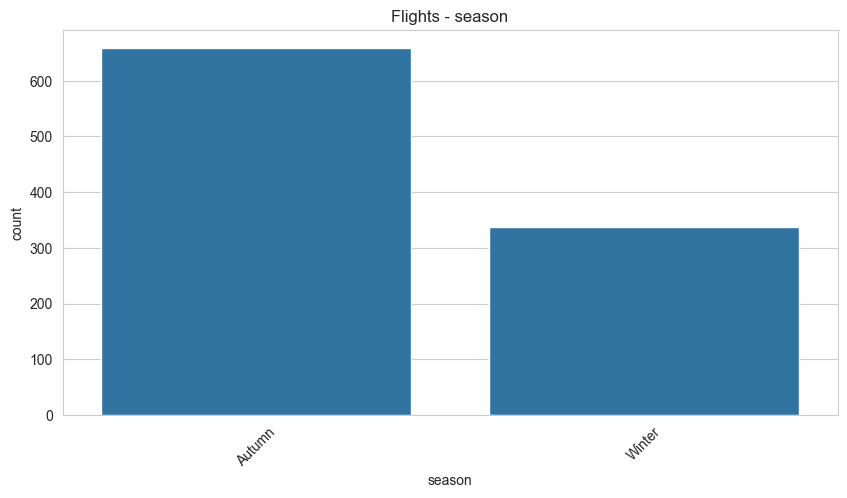

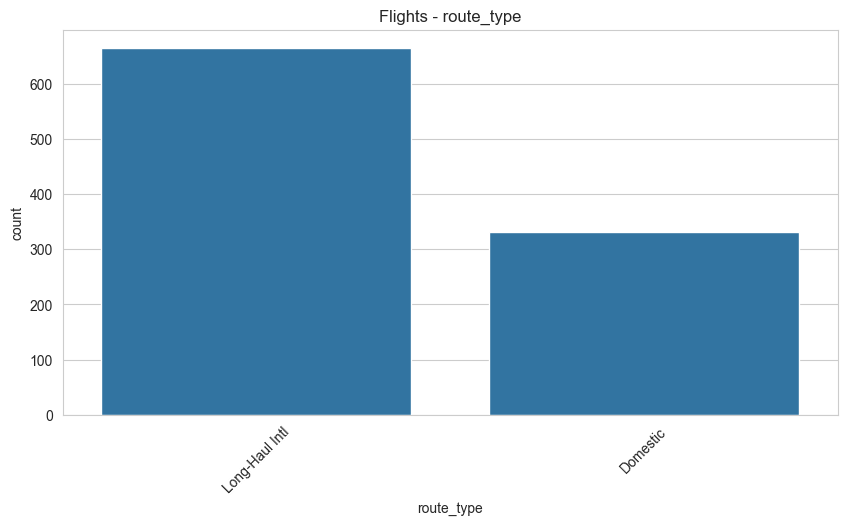

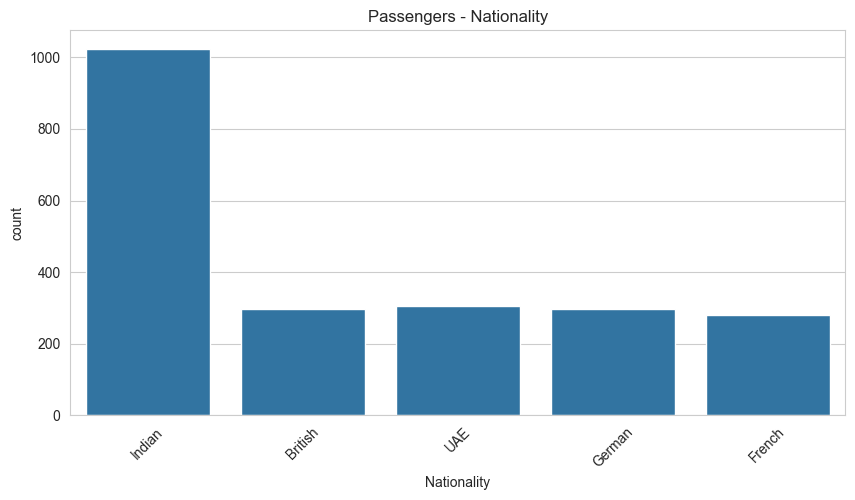

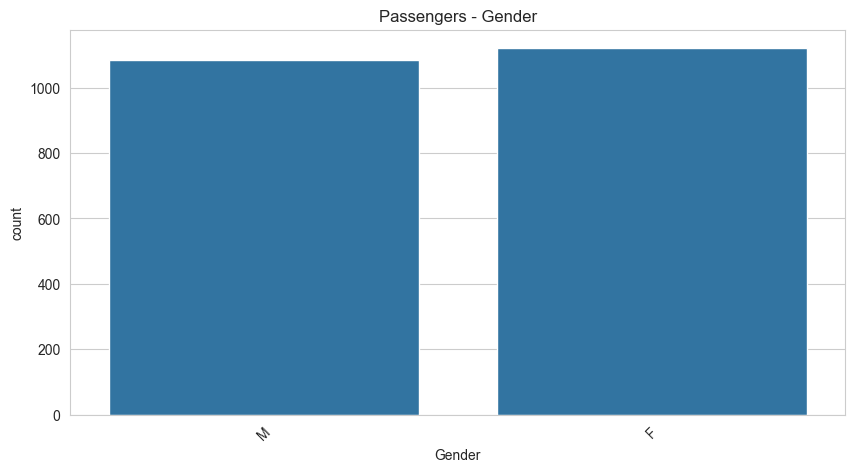

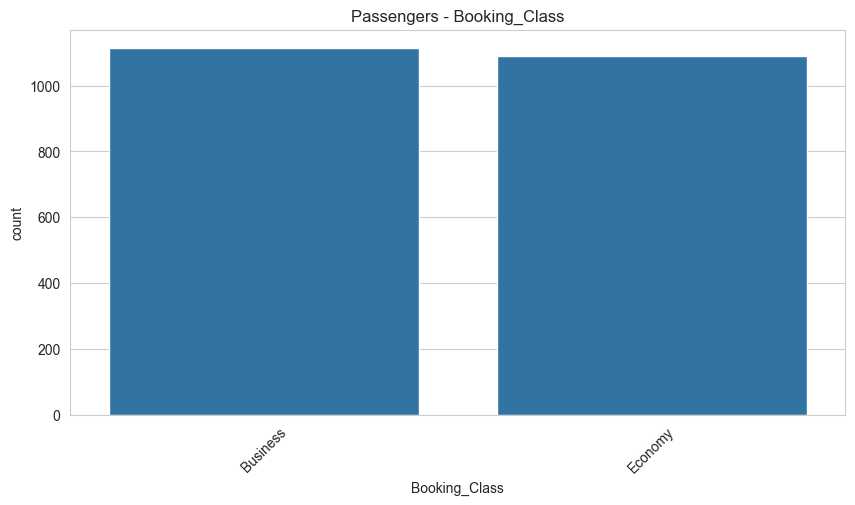

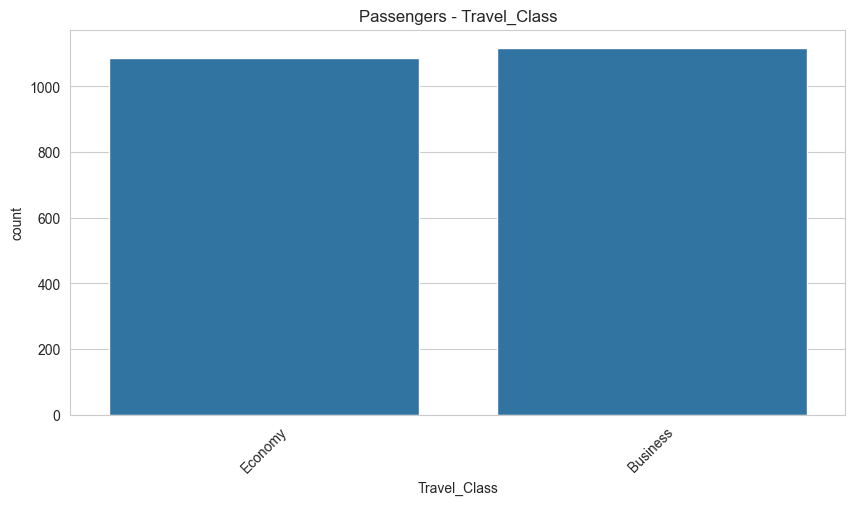

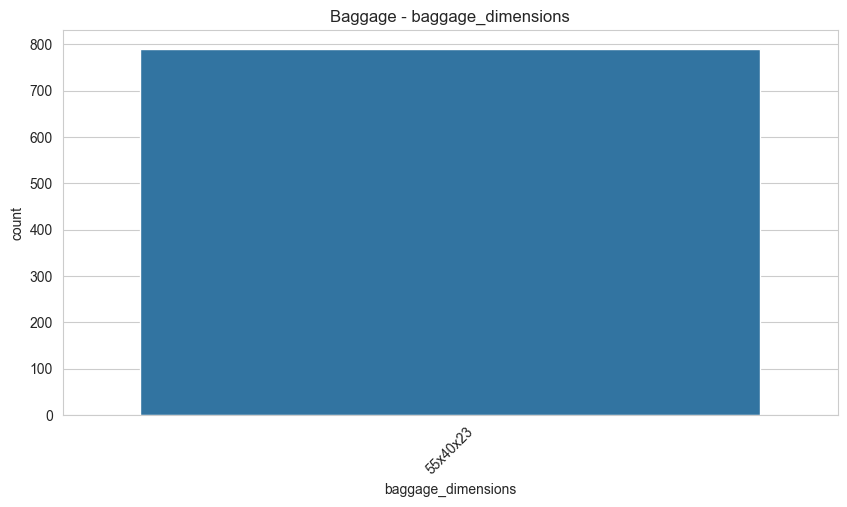

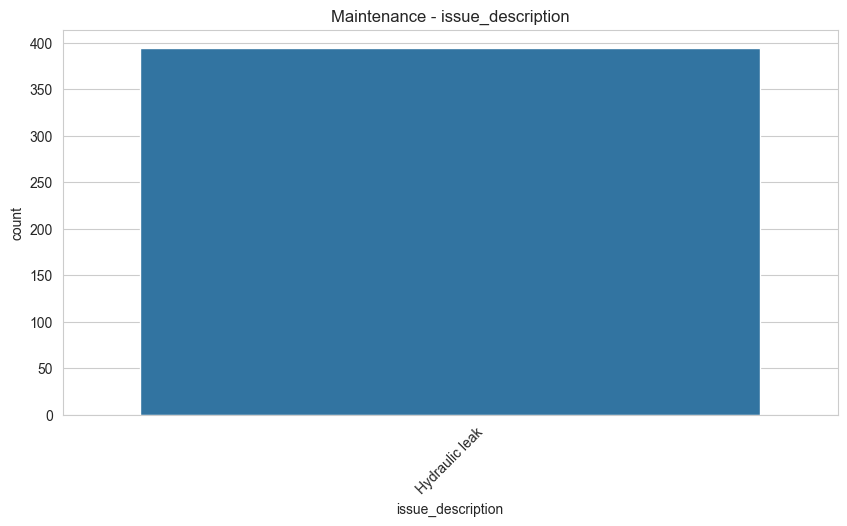

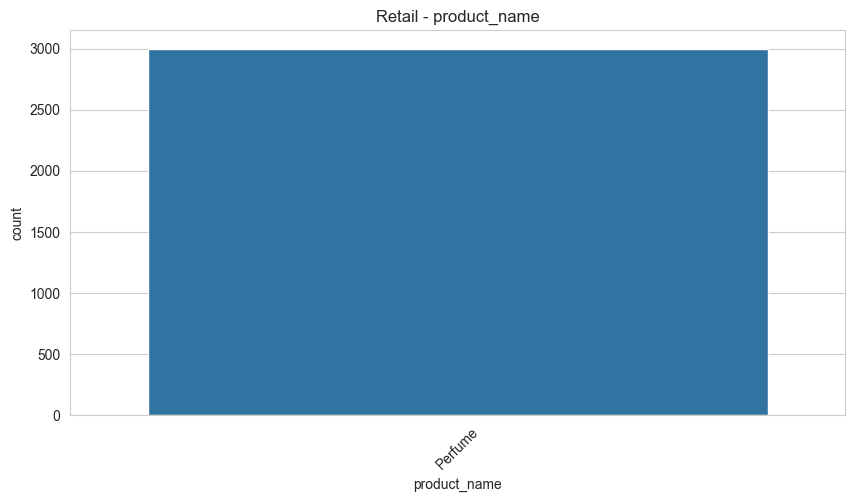

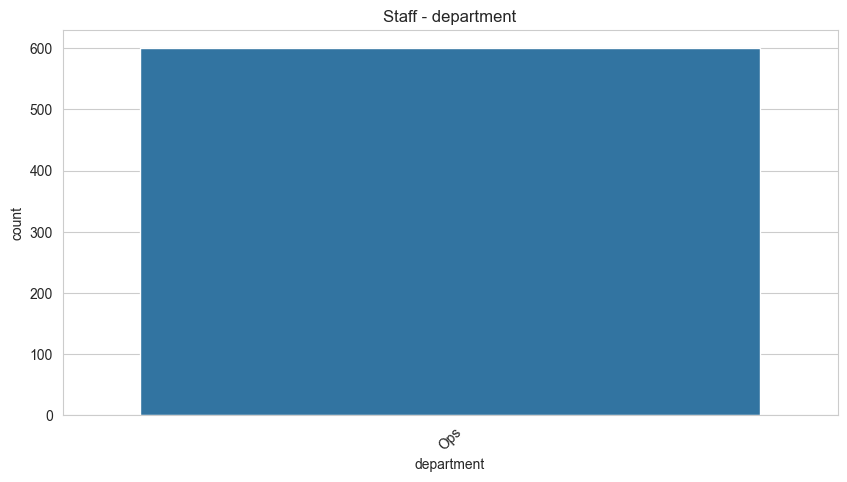

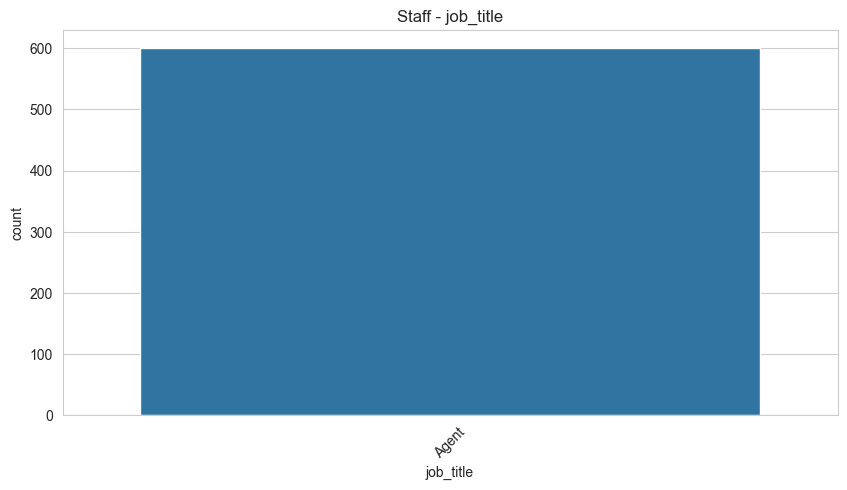

In [368]:
for name, df in datasets.items():

    categorical = df.select_dtypes(include="object").columns

    for col in categorical:

        if df[col].nunique() <= 20:

            plt.figure(figsize=(10,5))

            sns.countplot(data=df, x=col)

            plt.xticks(rotation=45)

            plt.title(f"{name} - {col}")

            plt.show()

In [369]:
flight_df = flights.copy()
numeric_columns = flight_df.select_dtypes(include=np.number).columns.tolist()

print("Numeric Columns:\n")
print(numeric_columns)

Numeric Columns:

['seat_capacity', 'passenger_count', 'departure_delay_minutes', 'distance_km', 'flight_duration_minutes', 'load_factor_percent', 'fuel_consumption', 'weather_severity_index']


In [370]:
categorical_columns = flight_df.select_dtypes(include="object").columns.tolist()

print("Categorical Columns:\n")
print(categorical_columns)

Categorical Columns:

['flight_id', 'airline_name', 'airline_code', 'destination_airport', 'aircraft_type', 'aircraft_registration', 'delay_reason', 'gate', 'delay_category', 'shift', 'day_of_week', 'season', 'route_type']


In [371]:
flight_ml = flight_df.copy()

encoders = {}

for col in flight_ml.select_dtypes(include="object").columns:

    encoder = LabelEncoder()

    flight_ml[col] = encoder.fit_transform(
        flight_ml[col].astype(str)
    )

    encoders[col] = encoder

In [372]:
flight_ml.head()

,flight_id,airline_name,airline_code,destination_airport,scheduled_departure,actual_departure,scheduled_arrival,actual_arrival,aircraft_type,aircraft_registration,seat_capacity,passenger_count,departure_delay_minutes,delay_reason,gate,boarding_completed,distance_km,flight_duration_minutes,boarding_start_time,is_diverted,delay_category,load_factor_percent,fuel_consumption,weather_severity_index,shift,day_of_week,is_weekend,season,route_type
0,753,10,9,10,2024-11-21 19:06:25,2024-11-21 19:06:25,2024-11-21 23:06:25,2024-11-22 03:06:25,3,691,180,178,0,4,21,True,3525,17512,2024-11-21 18:51:25,False,1,98.95,84,0.6125,0,4,False,0,1
1,761,10,9,6,2024-10-21 08:23:19,2024-10-21 08:23:19,2024-10-21 16:23:19,2024-10-21 16:23:19,2,105,316,257,0,4,33,True,6501,21691,2024-10-21 08:08:19,False,1,81.46,86,0.8839,0,1,False,0,1
2,454,2,5,13,2024-11-26 03:15:19,2024-11-26 03:15:19,2024-11-26 10:15:19,2024-11-26 07:15:19,0,447,276,252,0,1,40,True,6773,9623,2024-11-26 03:00:19,False,1,91.46,57,0.4408,0,5,False,0,1
3,262,3,3,10,2024-10-30 16:33:50,2024-10-30 16:33:50,2024-10-31 00:33:50,2024-10-30 20:33:50,0,403,336,290,0,4,24,True,5707,35419,2024-10-30 16:18:50,False,1,86.50,148,0.0371,0,6,False,0,1
4,324,4,4,6,2024-10-03 16:43:44,2024-10-03 16:43:44,2024-10-03 20:43:44,2024-10-04 01:43:44,2,374,315,232,0,1,1,True,1506,37097,2024-10-03 16:28:44,False,1,73.79,115,0.5123,0,4,False,0,1


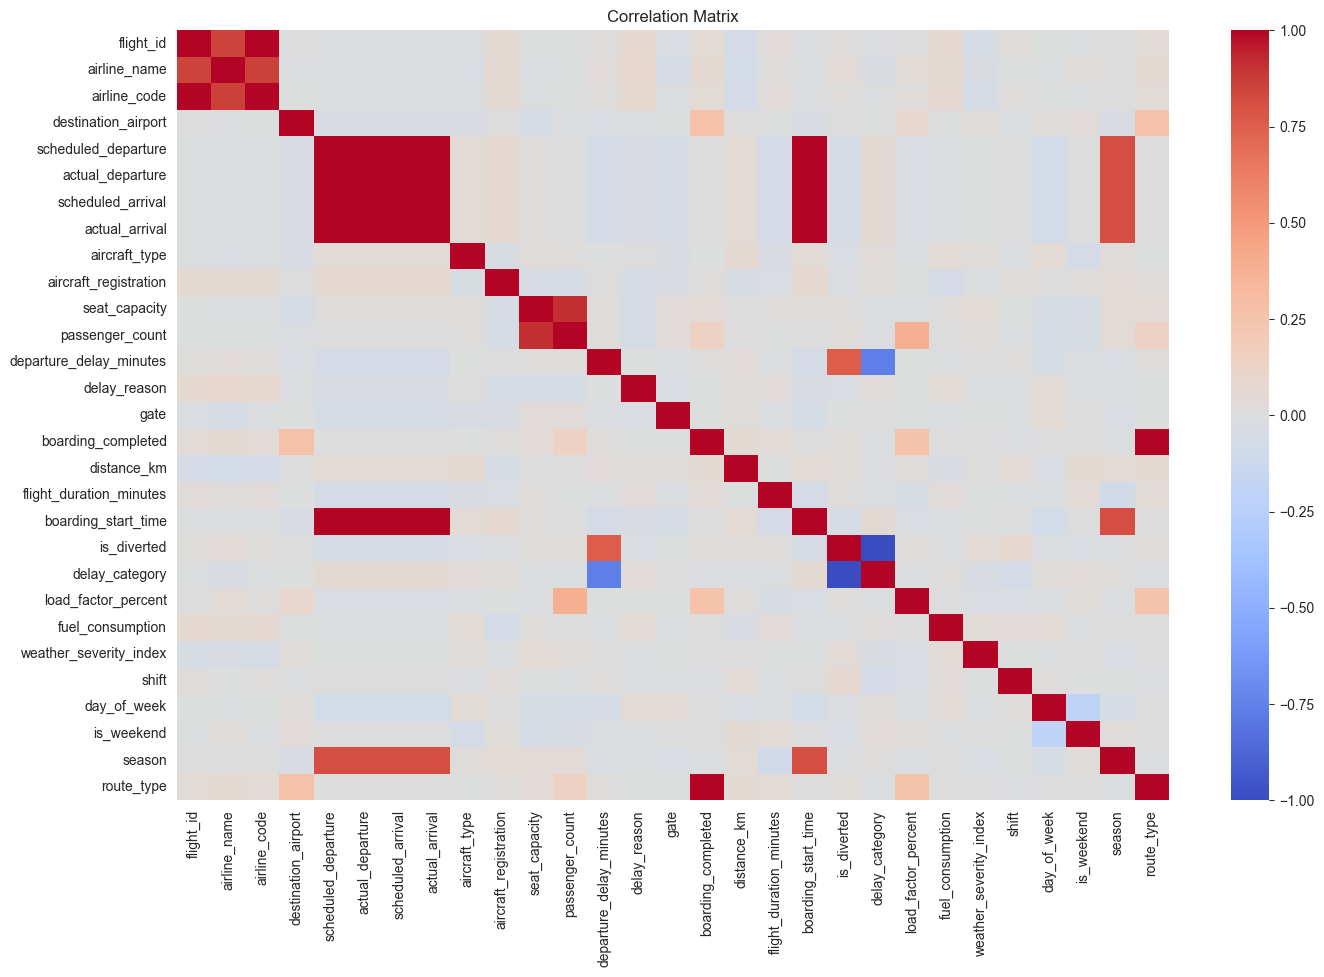

In [373]:
# Correlation
plt.figure(figsize=(16,10))

sns.heatmap(
    flight_ml.corr(),
    cmap="coolwarm",
    annot=False
)

plt.title("Correlation Matrix")

plt.show()

In [374]:

# print(target_column)
# target_column = "fuel_consumption"
target_column = "load_factor_percent"
# target_column = "departure_delay_minutes"

X = flight_ml.drop(columns=[target_column])

y = flight_ml[target_column]

In [375]:
date_columns = flight_ml.select_dtypes(include=["datetime64[ns]"]).columns

flight_ml.drop(columns=date_columns, inplace=True)

print("Removed:", list(date_columns))

Removed: ['scheduled_departure', 'actual_departure', 'scheduled_arrival', 'actual_arrival', 'boarding_start_time']


In [376]:
X = flight_ml.drop(columns=[target_column])

y = flight_ml[target_column]

In [377]:
X_train, X_test, y_train, y_test = train_test_split(

    X,
    y,
    test_size=0.2,
    random_state=42

)

In [378]:
# Standard Scaling
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)

X_test = scaler.transform(X_test)

In [399]:
# Linear Regression
linear_model = LinearRegression()

linear_model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [380]:
# Actual vs Predicted
prediction = linear_model.predict(X_test)

In [381]:
mae = mean_absolute_error(y_test, prediction)

rmse = np.sqrt(
    mean_squared_error(y_test, prediction)
)

r2 = r2_score(y_test, prediction)

print("MAE :", mae)
print("RMSE:", rmse)
print("R2  :", r2)

MAE : 1.1498966077853965
RMSE: 1.5679646054147727
R2  : 0.9555892185060039


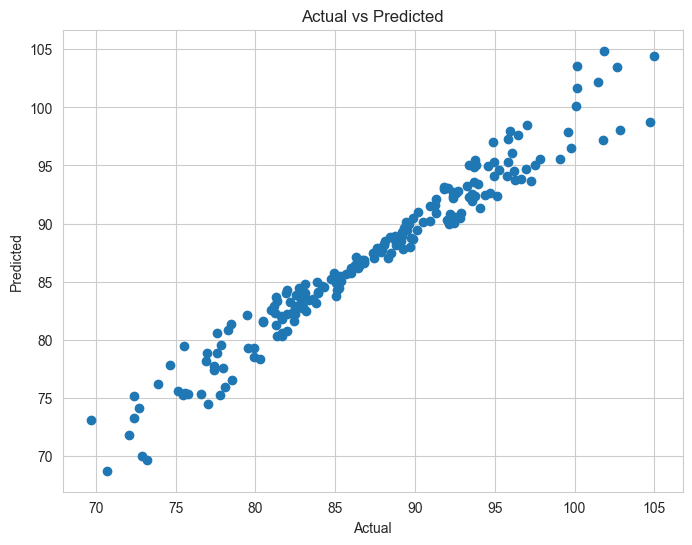

In [382]:
plt.figure(figsize=(8,6))

plt.scatter(
    y_test,
    prediction
)

plt.xlabel("Actual")

plt.ylabel("Predicted")

plt.title("Actual vs Predicted")

plt.show()


In [383]:
target_column = "fuel_consumption"
X = flight_ml.drop(columns=[target_column])

y = flight_ml[target_column]


In [384]:
X_train, X_test, y_train, y_test = train_test_split(

    X,
    y,
    test_size=0.2,
    random_state=42

)

In [385]:
# Standard Scaling
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)

X_test = scaler.transform(X_test)

In [386]:
# Linear Regression
linear_model = LinearRegression()

linear_model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [387]:
# Feature Importance
importance = pd.DataFrame({

    "Feature":X.columns,

    "Coefficient":linear_model.coef_

})

importance = importance.sort_values(

    by="Coefficient",

    ascending=False

)

importance

,Feature,Coefficient
6,seat_capacity,22.045069
16,load_factor_percent,8.723085
0,flight_id,8.303690
9,delay_reason,1.700872
17,weather_severity_index,1.203920
4,aircraft_type,1.097586
21,season,0.904652
18,shift,0.650727
14,is_diverted,0.541788
13,flight_duration_minutes,0.501951


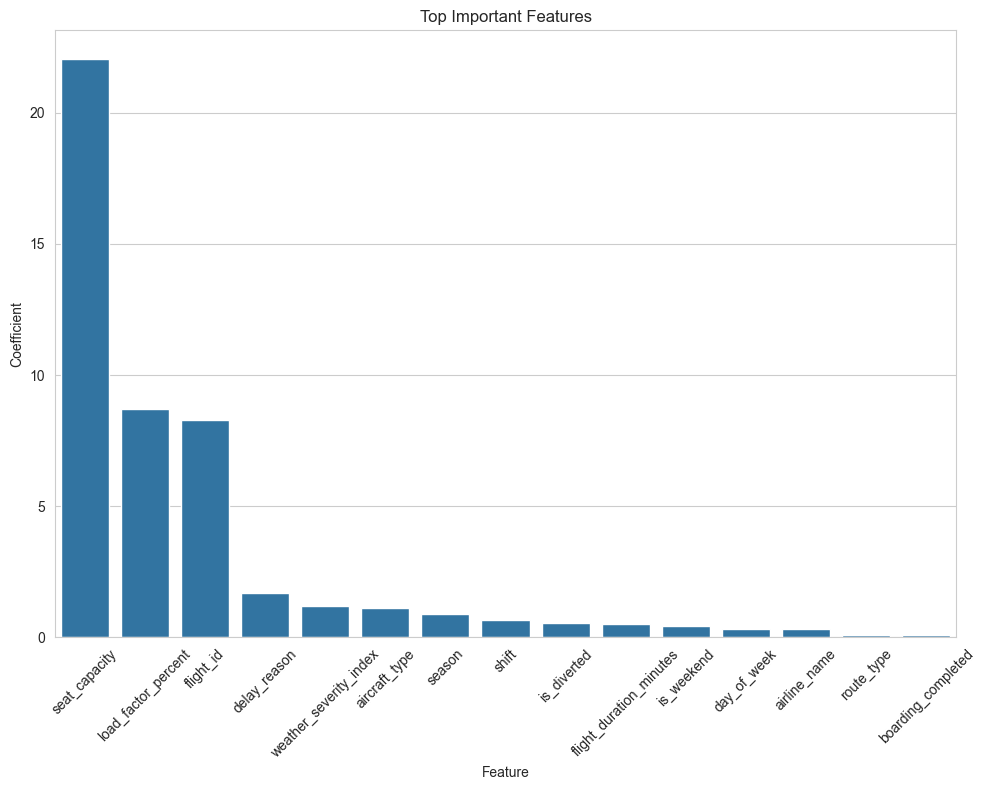

In [388]:
plt.figure(figsize=(10,8))

sns.barplot(

    data=importance.head(15),

    x="Feature",

    y="Coefficient"

)

plt.title("Top Important Features")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [389]:
print(classification_df["delay_category"].value_counts())

delay_category
1    689
0    307
Name: count, dtype: int64


In [390]:
classification_df = flight_ml.copy()

target = "delay_category"

X = classification_df.drop(
    columns=[
        target,
        "flight_id",
        "departure_delay_minutes"
    ],
    errors="ignore"
)
y = classification_df[target]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [391]:
classifier = LogisticRegression(max_iter=1000)

classifier.fit(X_train, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [392]:
prediction = classifier.predict(X_test)

              precision    recall  f1-score   support

           0       0.88      0.92      0.90        62
           1       0.96      0.94      0.95       138

    accuracy                           0.94       200
   macro avg       0.92      0.93      0.93       200
weighted avg       0.94      0.94      0.94       200



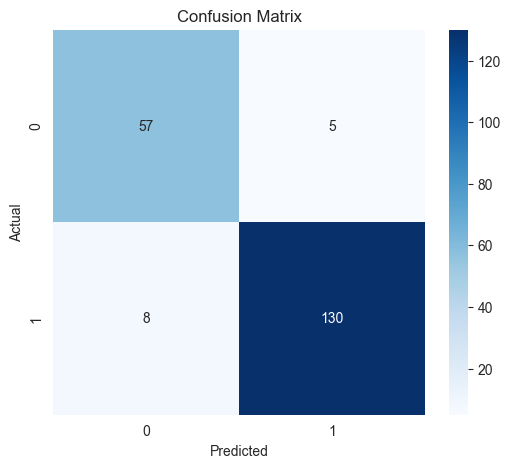

In [393]:
print(classification_report(y_test, prediction))

cm = confusion_matrix(y_test, prediction)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [394]:
X = classification_df.drop(columns=[target, "flight_id"], errors="ignore")

X = classification_df.drop(
    columns=[
        "flight_id",
        "delay_category",
        "departure_delay_minutes",
        "delay_reason"
    ],
    errors="ignore"
)

In [395]:
# Decision tree
dt = DecisionTreeClassifier(
    random_state=42,
    max_depth=5
)

dt.fit(X_train, y_train)

dt_prediction = dt.predict(X_test)

print(classification_report(y_test, dt_prediction))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        62
           1       1.00      1.00      1.00       138

    accuracy                           1.00       200
   macro avg       1.00      1.00      1.00       200
weighted avg       1.00      1.00      1.00       200



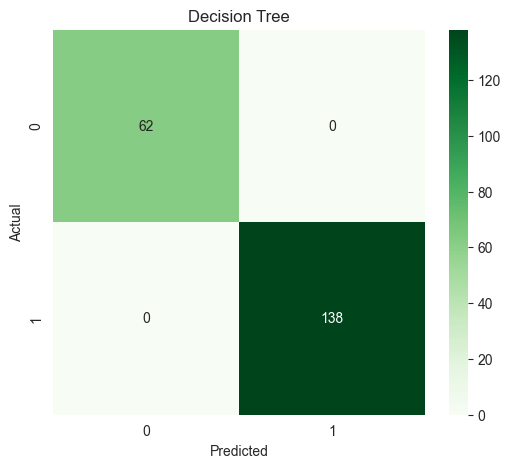

In [396]:
cm = confusion_matrix(y_test, dt_prediction)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Greens"
)

plt.title("Decision Tree")

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.show()

In [397]:
# Random Forest
rf = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

rf.fit(X_train, y_train)

rf_prediction = rf.predict(X_test)

print(classification_report(y_test, rf_prediction))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        62
           1       1.00      1.00      1.00       138

    accuracy                           1.00       200
   macro avg       1.00      1.00      1.00       200
weighted avg       1.00      1.00      1.00       200



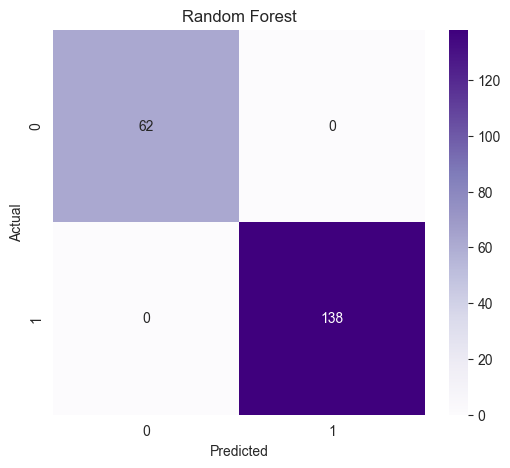

In [398]:
cm = confusion_matrix(y_test, rf_prediction)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Purples"
)

plt.title("Random Forest")

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.show()